## 1. Import Required Libraries

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add rosbag_loader to path
sys.path.insert(0, str(Path.cwd().parent))

from rosbag_loader import inspect_bag_topics, load_bag_topics, BagData

sns.set_style('darkgrid')
%matplotlib inline

## 2. Set Bag Path and Inspect Topics

In [2]:
# Use the first available bag
bag_path = 'C:\\Users\\luchs\\MyData\\Education\\Master_TUM\\25WS\\Guided Research\\radar-iwr6843-driver\\rosbags\\backflips_2025-12-17-17-41-24.bag'#rosbags\\circle_forward_2025-12-17-17-37-38.bag' #rosbags\\backflips_2025-12-17-17-41-24.bag'
bag_path = "C:\\Users\\luchs\\MyData\\Education\\Master_TUM\\25WS\\Guided Research\\radar-iwr6843-driver\\rosbags\\circle_2025-12-17-17-21-37.bag"
# Inspect bag topics
topics_info = inspect_bag_topics(bag_path)


Bag inspection: C:\Users\luchs\MyData\Education\Master_TUM\25WS\Guided Research\radar-iwr6843-driver\rosbags\circle_2025-12-17-17-21-37.bag
Duration: 43.55 seconds

Topic                                              Type                                        Count
----------------------------------------------------------------------------------------------------
/angrybird2/active_reference/markers               visualization_msgs/Marker                   13181
/angrybird2/active_reference/path                  nav_msgs/Path                               13104
/angrybird2/agiros_pilot/enable                    std_msgs/Bool                                   3
/angrybird2/agiros_pilot/go_to_pose                geometry_msgs/PoseStamped                       1
/angrybird2/agiros_pilot/land                      std_msgs/Empty                                  1
/angrybird2/agiros_pilot/mpc_command               agiros_msgs/Command                         13086
/angrybird2/agiros_pilot/o

## 3. Load Rosbag Topics into Data Structures

In [3]:
# Load all topics
bag_data = load_bag_topics(bag_path, verbose=True)

# Display summary
print("\nData Summary:")
for key, value in bag_data.summary().items():
    print(f"  {key}: {value}")


Loading rosbag: circle_2025-12-17-17-21-37.bag
Duration: 43.55s
  Loading /mocap/angrybird2/pose...
  Loading /mocap/angrybird2/accel...
  Loading /angrybird2/agiros_pilot/state...
  Loading /angrybird2/agiros_pilot/odometry...
  Loading /angrybird2/imu...
  Loading /ti_mmwave/radar_scan_pcl_0...
  Loading /mmWaveDataHdl/RScanVelocity...
  Done!


Data Summary:
  bag_path: C:\Users\luchs\MyData\Education\Master_TUM\25WS\Guided Research\radar-iwr6843-driver\rosbags\circle_2025-12-17-17-21-37.bag
  duration_s: 43.551565647125244
  mocap_pose_samples: 4358
  mocap_accel_samples: 4389
  agiros_state_samples: 13151
  agiros_odometry_samples: 13169
  imu_samples: 43317
  radar_pcl_samples: 506
  radar_velocity_samples: 506


## 4. Examine Loaded Data

In [4]:
# MoCap Pose Data
if bag_data.mocap_pose:
    print("\nMoCap Pose (first 3 samples):")
    for pose in bag_data.mocap_pose[:3]:
        print(f"  t={pose.timestamp:.3f}: pos={pose.position}")
else:
    print("No MoCap Pose data found")


MoCap Pose (first 3 samples):
  t=1765988498.405: pos=[-0.54933094  0.17546879  0.12742933]
  t=1765988498.405: pos=[-0.54934294  0.1754706   0.1274344 ]
  t=1765988498.406: pos=[-0.5493311   0.17547017  0.12743068]


In [5]:
# Agiros State Data
if bag_data.agiros_state:
    print("\nAgiros State (first 3 samples):")
    for state in bag_data.agiros_state[:3]:
        print(f"  t={state.timestamp:.3f}: pos={state.position}, vel={state.velocity}")
else:
    print("No Agiros State data found")


Agiros State (first 3 samples):
  t=1765988498.404: pos=[-0.54933687  0.17546942  0.12742591], vel=[-1.24052389e-05  7.74510178e-05  1.03173635e-05]
  t=1765988498.404: pos=[-0.54933691  0.17546968  0.12742595], vel=[-1.23487325e-05  7.98053302e-05  1.14006487e-05]
  t=1765988498.404: pos=[-0.54933696  0.17546995  0.12742599], vel=[-1.22923876e-05  8.21529150e-05  1.24808383e-05]


In [6]:
# IMU Data
if bag_data.imu_data:
    print("\nIMU Data (first 3 samples):")
    for imu in bag_data.imu_data[:3]:
        print(f"  t={imu.timestamp:.3f}: accel={imu.linear_acceleration}, gyro={imu.angular_velocity}")
else:
    print("No IMU data found")


IMU Data (first 3 samples):
  t=1765988498.405: accel=[1.49112 3.00186 9.37836], gyro=[ 0.028 -0.037  0.266]
  t=1765988498.405: accel=[1.49112 3.00186 9.37836], gyro=[ 0.026 -0.037  0.265]
  t=1765988498.405: accel=[1.49112 3.00186 9.37836], gyro=[ 0.026 -0.037  0.263]


In [7]:
# Radar Data
if bag_data.radar_pcl:
    print("\nRadar Point Cloud (first 3 samples):")
    for pcl in bag_data.radar_pcl[:3]:
        print(f"  t={pcl.timestamp:.3f}: {pcl.num_points()} points")
else:
    print("No Radar Point Cloud data found")


Radar Point Cloud (first 3 samples):
  t=1765988505.974: 2 points
  t=1765988506.141: 1 points
  t=1765988506.241: 1 points


## 5. Convert to DataFrames for Analysis

In [8]:
# Convert MoCap Pose to DataFrame
if bag_data.mocap_pose:
    mocap_pose_df = pd.DataFrame([pose.to_dict() for pose in bag_data.mocap_pose])
    print("MoCap Pose DataFrame:")
    print(mocap_pose_df.head())
    print(f"Shape: {mocap_pose_df.shape}")

MoCap Pose DataFrame:
      timestamp         x         y         z        qx        qy        qz  \
0  1.765988e+09 -0.549331  0.175469  0.127429  0.162299 -0.078345  0.018555   
1  1.765988e+09 -0.549343  0.175471  0.127434  0.162310 -0.078343  0.018541   
2  1.765988e+09 -0.549331  0.175470  0.127431  0.162298 -0.078369  0.018537   
3  1.765988e+09 -0.549338  0.175472  0.127440  0.162300 -0.078326  0.018532   
4  1.765988e+09 -0.549330  0.175466  0.127434  0.162293 -0.078371  0.018560   

         qw  
0  0.983452  
1  0.983450  
2  0.983450  
3  0.983453  
4  0.983450  
Shape: (4358, 8)


In [9]:
# Convert Agiros State to DataFrame
if bag_data.agiros_state:
    agiros_state_df = pd.DataFrame([state.to_dict() for state in bag_data.agiros_state])
    print("Agiros State DataFrame:")
    print(agiros_state_df.head())
    print(f"Shape: {agiros_state_df.shape}")

Agiros State DataFrame:
      timestamp         x         y         z        vx        vy        vz  \
0  1.765988e+09 -0.549337  0.175469  0.127426 -0.000012  0.000077  0.000010   
1  1.765988e+09 -0.549337  0.175470  0.127426 -0.000012  0.000080  0.000011   
2  1.765988e+09 -0.549337  0.175470  0.127426 -0.000012  0.000082  0.000012   
3  1.765988e+09 -0.549338  0.175471  0.127423 -0.000065  0.000101 -0.000089   
4  1.765988e+09 -0.549339  0.175471  0.127423 -0.000066  0.000103 -0.000091   

         qx        qy        qz  ...        wx        wy        wz        ax  \
0  0.162296 -0.078354  0.018571  ...  0.001718 -0.000929  0.001730  0.000017   
1  0.162299 -0.078356  0.018573  ...  0.001718 -0.000929  0.001730  0.000017   
2  0.162302 -0.078358  0.018576  ...  0.001718 -0.000929  0.001730  0.000017   
3  0.162307 -0.078349  0.018567  ...  0.001994  0.000207 -0.000015 -0.000390   
4  0.162310 -0.078348  0.018568  ...  0.001994  0.000207 -0.000015 -0.000390   

         ay        a

In [10]:
# Convert IMU to DataFrame
if bag_data.imu_data:
    imu_df = pd.DataFrame([imu.to_dict() for imu in bag_data.imu_data])
    print("IMU DataFrame:")
    print(imu_df.head())
    print(f"Shape: {imu_df.shape}")

IMU DataFrame:
      timestamp       ax       ay       az     wx     wy     wz
0  1.765988e+09  1.49112  3.00186  9.37836  0.028 -0.037  0.266
1  1.765988e+09  1.49112  3.00186  9.37836  0.026 -0.037  0.265
2  1.765988e+09  1.49112  3.00186  9.37836  0.026 -0.037  0.263
3  1.765988e+09  1.49112  3.00186  9.37836  0.027 -0.037  0.264
4  1.765988e+09  1.49112  3.00186  9.37836  0.026 -0.038  0.262
Shape: (43317, 7)


## 6. Visualization: Trajectory Comparison

In [11]:
len(agiros_state_df['x'])

13151

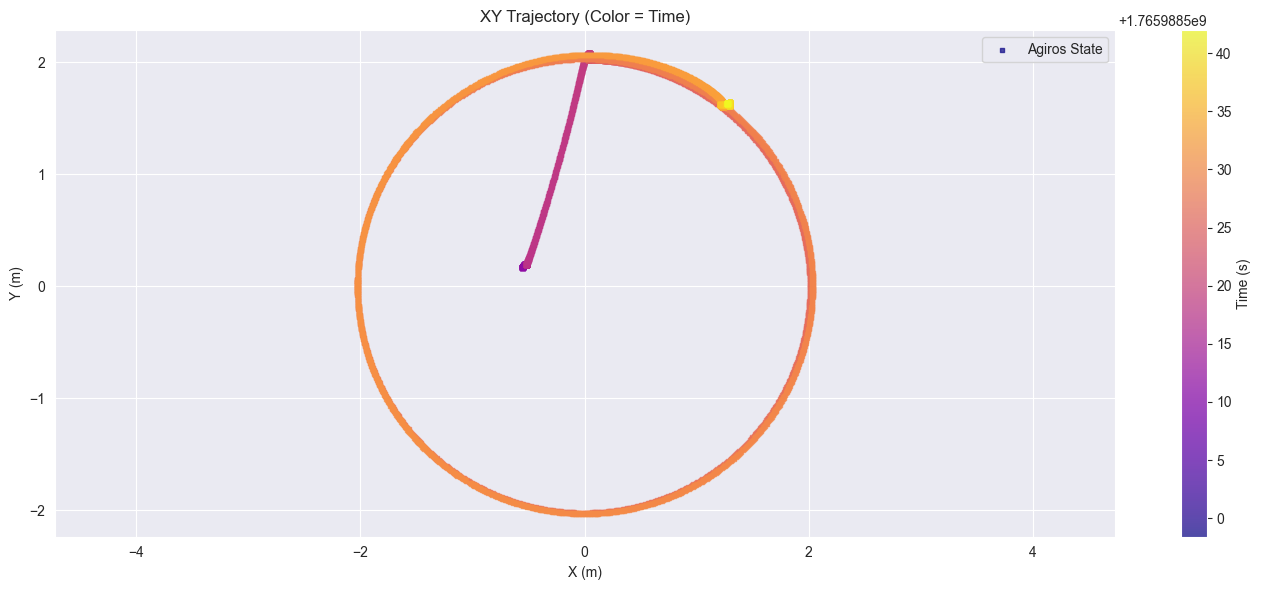

In [12]:
# Plot trajectories from different sensors with color gradient over time
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# # XY trajectory with color gradient
# if bag_data.mocap_pose and mocap_pose_df is not None:
#     points = ax.scatter(mocap_pose_df['x'], mocap_pose_df['y'], 
#                        c=mocap_pose_df['timestamp'], cmap='viridis', 
#                        s=10, alpha=0.7, label='MoCap Pose')
#     plt.colorbar(points, ax=ax, label='Time (s)')

if bag_data.agiros_state and agiros_state_df is not None:
    points2 = ax.scatter(agiros_state_df['x'], agiros_state_df['y'], 
                        c=agiros_state_df['timestamp'], cmap='plasma', 
                        s=10, alpha=0.7, marker='s', label='Agiros State')
    plt.colorbar(points2, ax=ax, label='Time (s)')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('XY Trajectory (Color = Time)')
ax.legend()
ax.grid(True)
ax.axis('equal')

plt.tight_layout()
plt.show()


In [13]:
imu_df

,timestamp,ax,ay,az,wx,wy,wz
0,1.765988e+09,1.49112,3.00186,9.37836,0.028,-0.037,0.266
1,1.765988e+09,1.49112,3.00186,9.37836,0.026,-0.037,0.265
2,1.765988e+09,1.49112,3.00186,9.37836,0.026,-0.037,0.263
3,1.765988e+09,1.49112,3.00186,9.37836,0.027,-0.037,0.264
4,1.765988e+09,1.49112,3.00186,9.37836,0.026,-0.038,0.262
...,...,...,...,...,...,...,...
43312,1.765989e+09,1.28511,2.79585,9.12330,0.030,-0.035,0.257
43313,1.765989e+09,1.28511,2.79585,9.12330,0.032,-0.035,0.258
43314,1.765989e+09,1.28511,2.79585,9.11349,0.034,-0.035,0.257
43315,1.765989e+09,1.28511,2.79585,9.12330,0.035,-0.034,0.259


## 7. Visualization: IMU Acceleration

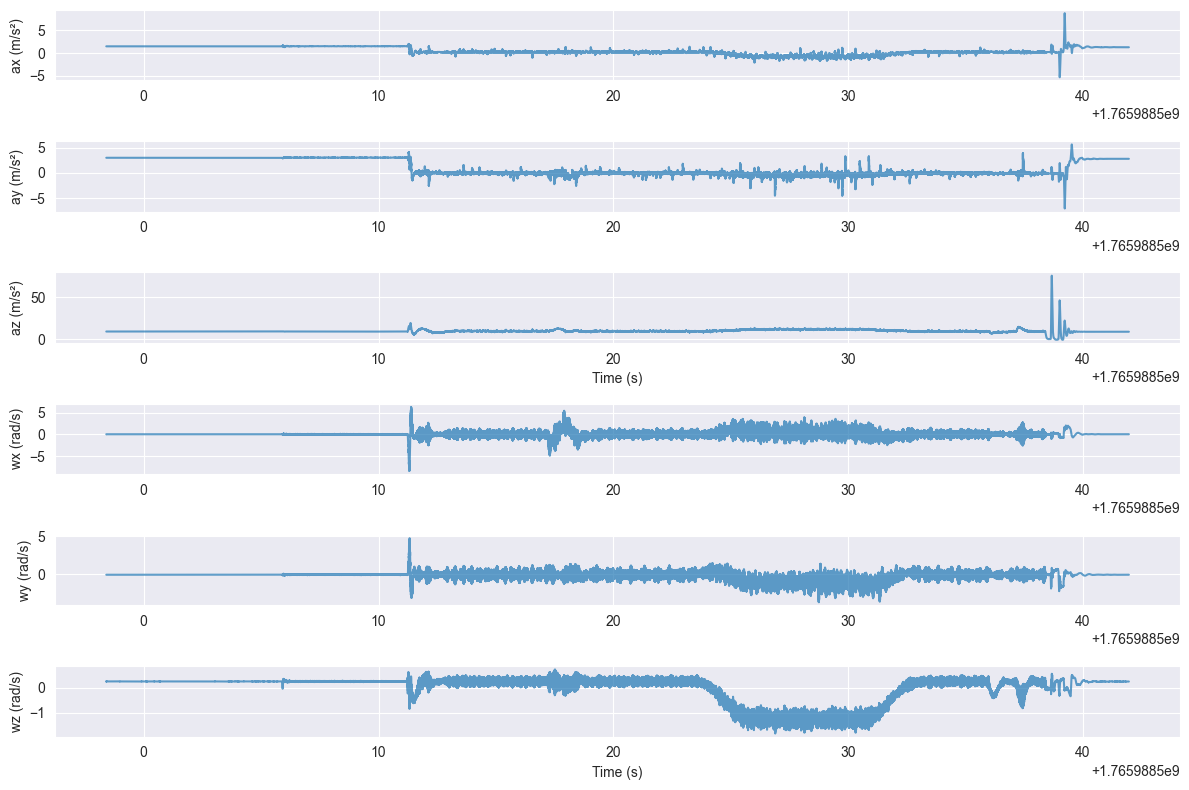

In [14]:
# Plot IMU acceleration
if bag_data.imu_data and imu_df is not None:
    fig, axes = plt.subplots(6, 1, figsize=(12, 8))
    
    axes[0].plot(imu_df['timestamp'], imu_df['ax'], alpha=0.7)
    axes[0].set_ylabel('ax (m/s²)')
    axes[0].grid(True)
    
    axes[1].plot(imu_df['timestamp'], imu_df['ay'], alpha=0.7)
    axes[1].set_ylabel('ay (m/s²)')
    axes[1].grid(True)
    
    axes[2].plot(imu_df['timestamp'], imu_df['az'], alpha=0.7)
    axes[2].set_ylabel('az (m/s²)')
    axes[2].set_xlabel('Time (s)')
    axes[2].grid(True)
    
    axes[3].plot(imu_df['timestamp'], imu_df['wx'], alpha=0.7)
    axes[3].set_ylabel('wx (rad/s)')
    axes[3].grid(True)
    
    axes[4].plot(imu_df['timestamp'], imu_df['wy'], alpha=0.7)
    axes[4].set_ylabel('wy (rad/s)')
    axes[4].grid(True)
    
    axes[5].plot(imu_df['timestamp'], imu_df['wz'], alpha=0.7)
    axes[5].set_ylabel('wz (rad/s)')
    axes[5].set_xlabel('Time (s)')
    axes[5].grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("No IMU data to plot")

## 8. Synchronization Analysis

Find time bounds where all available sensors have data for synchronized processing.

In [15]:
# Get synchronized time bounds
t_min, t_max = bag_data.get_sync_time_bounds()

print(f"\nSynchronization Analysis:")
print(f"  Sync time range: {t_min:.3f} to {t_max:.3f}")
print(f"  Sync duration: {t_max - t_min:.3f} seconds")
print(f"\n  Individual sensor time ranges:")

if bag_data.mocap_pose:
    dt = bag_data.mocap_pose[-1].timestamp - bag_data.mocap_pose[0].timestamp
    print(f"    MoCap Pose: {bag_data.mocap_pose[0].timestamp:.3f} - {bag_data.mocap_pose[-1].timestamp:.3f} ({dt:.3f}s)")

if bag_data.agiros_state:
    dt = bag_data.agiros_state[-1].timestamp - bag_data.agiros_state[0].timestamp
    print(f"    Agiros State: {bag_data.agiros_state[0].timestamp:.3f} - {bag_data.agiros_state[-1].timestamp:.3f} ({dt:.3f}s)")

if bag_data.imu_data:
    dt = bag_data.imu_data[-1].timestamp - bag_data.imu_data[0].timestamp
    print(f"    IMU: {bag_data.imu_data[0].timestamp:.3f} - {bag_data.imu_data[-1].timestamp:.3f} ({dt:.3f}s)")

if bag_data.radar_pcl:
    dt = bag_data.radar_pcl[-1].timestamp - bag_data.radar_pcl[0].timestamp
    print(f"    Radar PCL: {bag_data.radar_pcl[0].timestamp:.3f} - {bag_data.radar_pcl[-1].timestamp:.3f} ({dt:.3f}s)")


Synchronization Analysis:
  Sync time range: 1765988505.974 to 1765988540.141
  Sync duration: 34.167 seconds

  Individual sensor time ranges:
    MoCap Pose: 1765988498.405 - 1765988541.949 (43.543s)
    Agiros State: 1765988498.404 - 1765988541.954 (43.550s)
    IMU: 1765988498.405 - 1765988541.955 (43.549s)
    Radar PCL: 1765988505.974 - 1765988540.141 (34.167s)


## 9. Usage for Factor Graph Pipeline

Example of how to access data for factor graph construction:

In [16]:
# Example: Iterate through synchronized data for factor graph
print("\nExample: Iterating through synchronized data for factor graph construction")
print("="*60)

t_min, t_max = bag_data.get_sync_time_bounds()

# Create index mapping for synchronized data
sync_mocap_idx = [i for i, pose in enumerate(bag_data.mocap_pose) 
                  if t_min <= pose.timestamp <= t_max]
sync_imu_idx = [i for i, imu in enumerate(bag_data.imu_data) 
                if t_min <= imu.timestamp <= t_max]

print(f"\nSynchronized data indices:")
print(f"  MoCap Pose: {len(sync_mocap_idx)} samples")
print(f"  IMU: {len(sync_imu_idx)} samples")

# Example: Get first synchronized pose and IMU measurement
if sync_mocap_idx and sync_imu_idx:
    pose = bag_data.mocap_pose[sync_mocap_idx[0]]
    imu = bag_data.imu_data[sync_imu_idx[0]]
    
    print(f"\nFirst synchronized measurements:")
    print(f"  MoCap Pose: pos={pose.position}, ori={pose.orientation}")
    print(f"  IMU: accel={imu.linear_acceleration}, gyro={imu.angular_velocity}")
    print(f"  Time diff: {abs(pose.timestamp - imu.timestamp):.6f} seconds")


Example: Iterating through synchronized data for factor graph construction

Synchronized data indices:
  MoCap Pose: 3417 samples
  IMU: 33942 samples

First synchronized measurements:
  MoCap Pose: pos=[-0.54899036  0.17555469  0.12764587], ori=[ 0.16375123 -0.07778173  0.01622481  0.98329665]
  IMU: accel=[1.48131 3.09015 9.39798], gyro=[ 0.106 -0.062  0.293]
  Time diff: 0.004056 seconds
